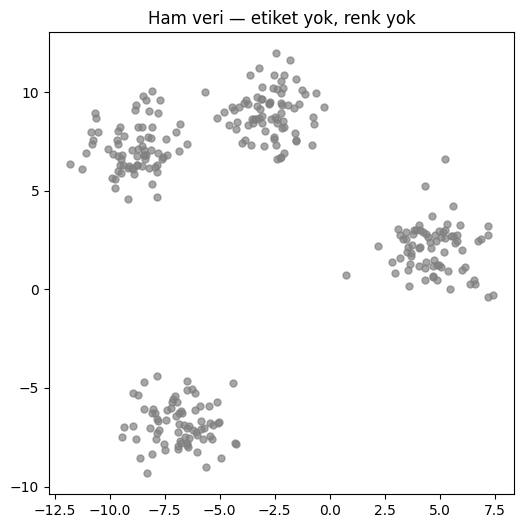

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y_true = make_blobs(
    n_samples=300, centers=4, cluster_std=1.2, random_state=42
)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.7, color='gray')
plt.title('Ham veri — etiket yok, renk yok')
plt.show()

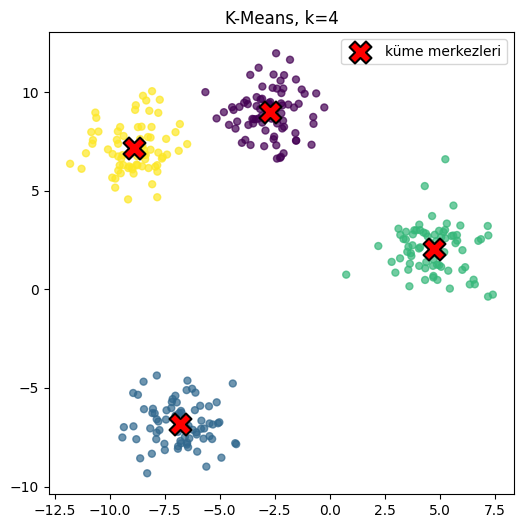

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=25, alpha=0.7, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, marker='X',
            edgecolors='black', linewidths=1.5, label='küme merkezleri')
plt.title('K-Means, k=4')
plt.legend()
plt.show()

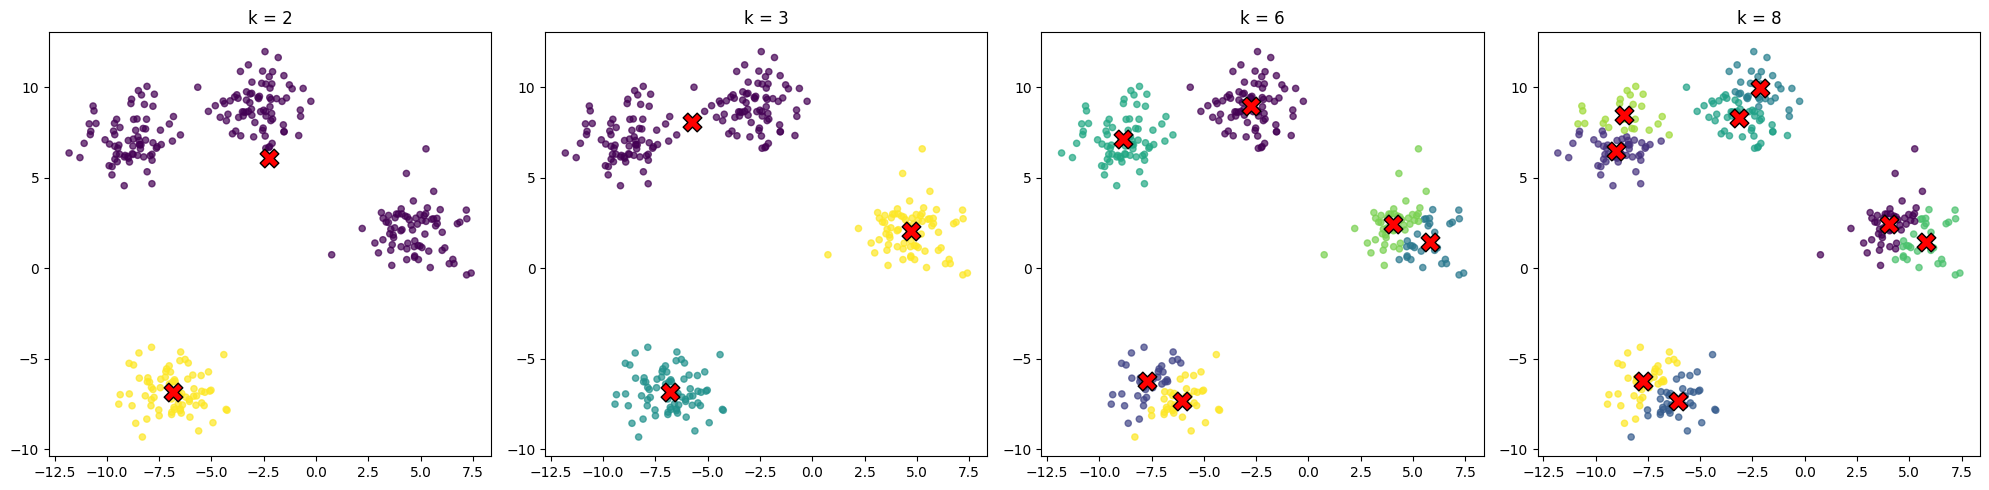

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, k in zip(axes, [2, 3, 6, 8]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=lab, s=20, alpha=0.7, cmap='viridis')
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='red', s=180, marker='X', edgecolors='black')
    ax.set_title(f'k = {k}')

plt.tight_layout()
plt.show()

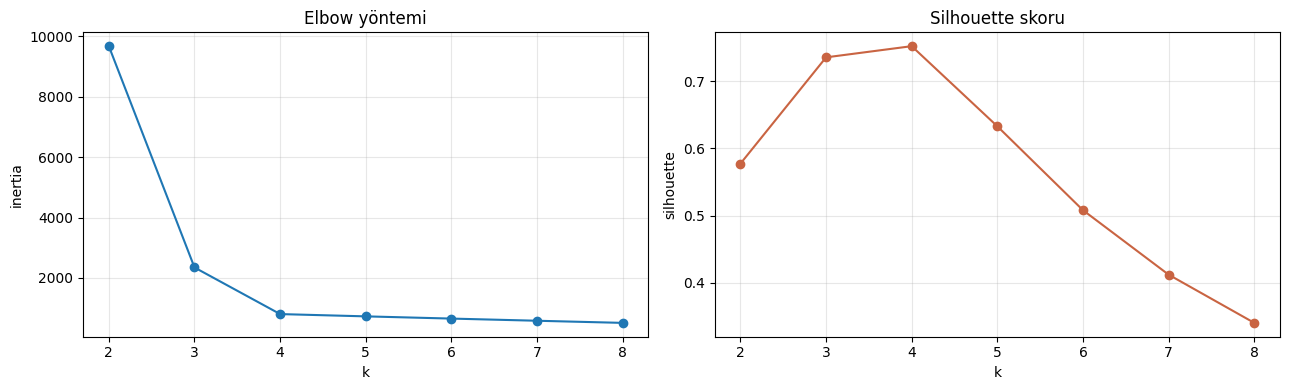

In [ ]:
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(ks), inertias, marker='o')
ax1.set_xlabel('k'); ax1.set_ylabel('inertia')
ax1.set_title('Elbow yöntemi')
ax1.grid(alpha=0.3)

ax2.plot(list(ks), sils, marker='o', color='#C96442')
ax2.set_xlabel('k'); ax2.set_ylabel('silhouette')
ax2.set_title('Silhouette skoru')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Gözlemler

- Ham noktalara renksiz baktığımda 4 grup net şekilde ayırt ediliyordu.
  K-Means k=4 ile çalıştırıldığında bulduğu gruplar ve merkezler gözle
  gördüğümle örtüştü.
- Yanlış k verdiğimde algoritma hiç şikayet etmedi, hata vermedi, uyarmadı —
  ne istediysem onu üretti. İki farklı bozulma şekli gördüm:
  * k=2 ve 3: aralarında kocaman boşluk olan ayrı blob'ları tek küme sayıp
    birleştirdi.
  * k=6 ve 8: iki merkezi AYNI blob'un içine yerleştirip homojen bir grubu
    keyfi olarak ortasından böldü. Orada gerçek bir sınır yok, uydurulmuş bir
    sınır var.
- K-Means'in kendi ölçütü inertia, ama bu k arttıkça HER ZAMAN düşüyor
  (k=nokta sayısı olsa sıfır olurdu). Yani "en düşük inertia'yı seç" demek
  her zaman en büyük k'yı seçmek olurdu — işe yaramaz.
- Elbow grafiğinde ilk bakışta dirseği k=3'te sandım. Sayılara bakınca yanlış
  olduğunu gördüm: 3→4 geçişi hâlâ 1541 puan kazandırıyor, ama 4'ten sonraki
  her adım sadece ~72. Yani asıl düzleşme k=4'te başlıyor. 2→3 düşüşü çok
  büyük olduğu için (7320) grafiği eziyor ve sonraki gerçek düşüşü görsel
  olarak küçük gösteriyor. Elbow'un zayıflığı tam da bu: "dirsek nerede"
  gözle verilen öznel bir karar.
- Silhouette daha net konuştu, tepe k=4'te (0.752). Ama k=3 de çok yakın
  (0.735), yani o da kesin bir hakem değil.
- Sonuç: K-Means'in içeriden "yanlış sayı verdin" deme yolu yok. Elbow ve
  silhouette dışarıdan bakan teşhis araçları ve ikisi de kesin cevap vermiyor.
  Burada doğru cevabı biliyorum çünkü veriyi ben centers=4 ile ürettim —
  gerçek bir projede o bilgi olmayacak.